<a href="https://colab.research.google.com/github/Cicikuss/Learning-to-Build-Autonomous-Car/blob/main/Deep_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [ ]:
np.random.seed(0)

In [ ]:
n_pts = 500
X , y = datasets.make_circles(n_samples=n_pts,random_state=123,noise=0.1,factor=0.2)


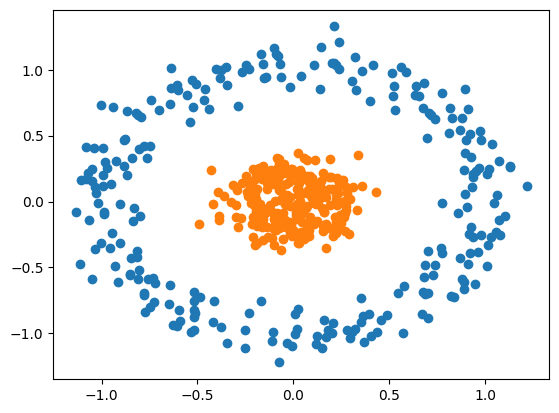

In [ ]:
plt.scatter(X[y==0,0],X[y==0,1])
plt.scatter(X[y==1,0],X[y==1,1])

In [ ]:
model = Sequential()
model.add(Dense(4,input_shape=(2,),activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))
model.compile(Adam(learning_rate=0.01),'binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
h = model.fit(x=X,y=y,verbose=1,batch_size=20,epochs=100,shuffle='true')

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5100 - loss: 0.6959   
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4160 - loss: 0.6934 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5240 - loss: 0.6932 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5240 - loss: 0.6922 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4620 - loss: 0.6910 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5580 - loss: 0.6918 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.6876 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6640 - loss: 0.6861 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6100 - loss: 0.6838 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6560 - loss: 0.6781 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7060 - loss: 0.6715 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

Text(0.5, 1.0, 'accuracy')

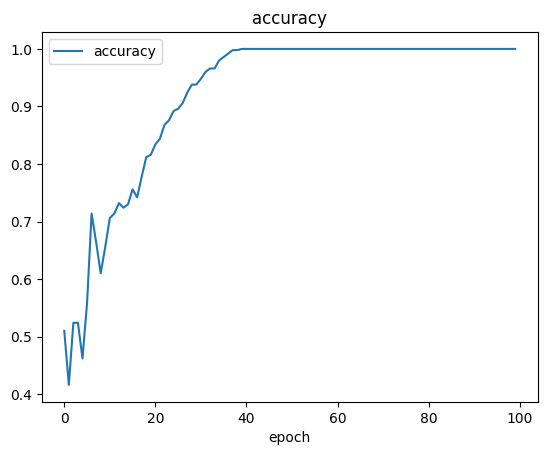

In [ ]:
plt.plot(h.history['accuracy'])
plt.xlabel("epoch")
plt.legend(["accuracy"])
plt.title("accuracy")

Text(0.5, 1.0, 'loss')

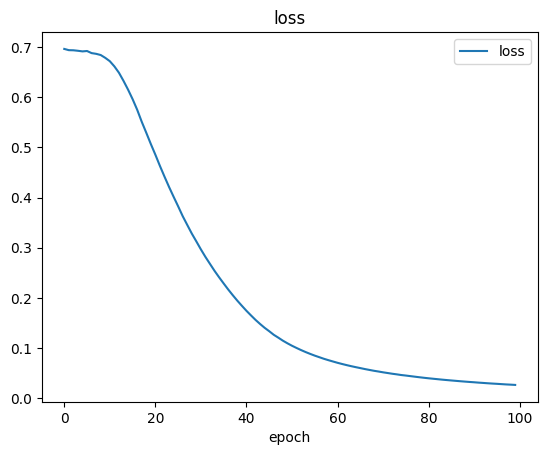

In [ ]:
plt.plot(h.history['loss'])
plt.xlabel("epoch")
plt.legend(["loss"])
plt.title("loss")

In [ ]:
def plot_decision_boundry(X,y,model):
  x_span = np.linspace(min(X[:,0])-0.25, max(X[:,0])+0.25, 50)
  y_span = np.linspace(min(X[:,1])-0.25, max(X[:,1])+0.25, 50)
  xx , yy = np.meshgrid(x_span , y_span)
  xx_ , yy_ = xx.ravel() , yy.ravel()
  grid = np.c_[xx_ , yy_]
  pred_func = model.predict(grid)
  z = pred_func.reshape(xx.shape)
  plt.contourf(xx, yy, z)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


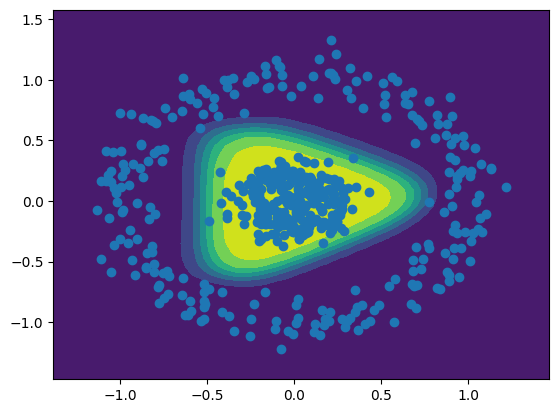

In [ ]:
plot_decision_boundry(X,y,model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
prediction is:  [[0.99064314]]


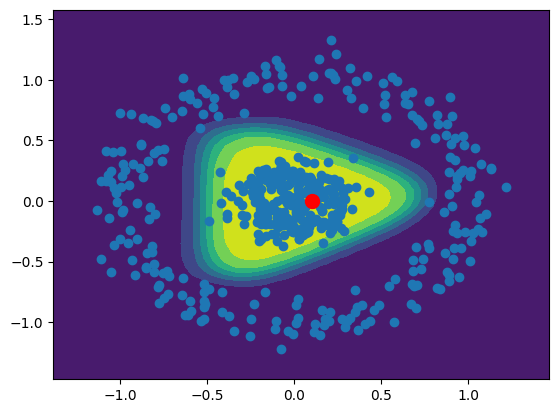

In [ ]:
plot_decision_boundry(X,y,model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])
point = np.array([[0.1,0]])
prediction = model.predict(point)
plt.plot([point[0][0]],[point[0][1]],marker='o',markersize=10,color="red")
print("prediction is: ",prediction)